# Notebook 5 — Anomaly Detection

## Overview

Anomaly detection is applied to the **test-set residuals** of the best forecasting model (N-BEATS v2). A residual is defined as `residual = actual − predicted`. Five independent detectors flag suspicious days; a majority-vote ensemble (≥ 3 out of 5) produces the final anomaly label. Results are analysed across three temporal periods: pre-COVID, in-COVID, and post-COVID.

---

## Models and Hyperparameters

### Feature Matrix

All five detectors operate on the same 9-dimensional scaled feature matrix (improvement over the original 5 features following Jesmeen et al.):

| Feature | Description |
|---|---|
| `residual` | Raw prediction error |
| `abs_residual` | Absolute prediction error |
| `z_residual` | Rolling 30-day z-score of the residual |
| `lag_residual_1d` | Residual of the previous day |
| `lag_residual_7d` | Residual of the same weekday last week |
| `rolling_mean_7d` | 7-day rolling mean of residuals |
| `rolling_std_7d` | 7-day rolling standard deviation of residuals |
| `dow` | Day of week (0–6) |
| `month` | Month (1–12) |

All features are standardised with `StandardScaler` before being fed to each detector.

---

### Contamination Calibration (shared across ML detectors)

Contamination is estimated per city from the empirical fraction of days with `|rolling z| > 3`, clamped to `[0.01, 0.10]`. A fallback of `0.022` is used if the empirical rate is zero.

---

### 1. Z-score (Rolling)

Flags a day as anomalous if its rolling z-score exceeds a fixed threshold. No model fitting required.

| Parameter | Value |
|---|---|
| Rolling window | 30 days |
| `min_periods` | 10 |
| Anomaly threshold | `|z| > 3` |

Using a rolling window (Zangrando et al.) rather than a global z-score prevents seasonal drift from masking true anomalies.

---

### 2. Isolation Forest

Tree-based method that isolates anomalies by randomly selecting a feature and a split value. Points that are isolated in fewer splits are more anomalous.

| Parameter | Value |
|---|---|
| `n_estimators` | 200 |
| `contamination` | calibrated per city (see above) |
| `random_state` | 42 |

---

### 3. Local Outlier Factor (LOF)

Density-based method that compares the local density of a point to the density of its neighbours. Points in low-density regions relative to their neighbours score as outliers.

| Parameter | Value |
|---|---|
| `n_neighbors` | 20 |
| `contamination` | calibrated per city |
| `novelty` | False (transductive) |

---

### 4. One-Class SVM (OC-SVM)

Kernel-based method that learns a tight boundary around the normal training distribution. Points outside the boundary are anomalies.

| Parameter | Value |
|---|---|
| `kernel` | RBF |
| `gamma` | `'scale'` |
| `nu` | calibrated contamination (upper bound on outlier fraction) |

---

### 5. K-Means (k = 2)

Partitions all days into two clusters. The cluster with the higher mean absolute residual is labelled as the anomaly cluster (Zhang et al.). Applied to the full 9-feature matrix rather than the 1-D residual to capture multi-dimensional outliers.

| Parameter | Value |
|---|---|
| `n_clusters` | 2 |
| `n_init` | 10 |
| `random_state` | 42 |

---

### 6. Ensemble (Majority Vote)

A day is flagged as anomalous if **at least 3 of the 5** individual detectors agree. No additional parameters; requires only the binary flags from the five methods above.

| Threshold | Value |
|---|---|
| Minimum detector agreement | ≥ 3 out of 5 |

# Notebook 7 (Improved) — Prediction-Based Anomaly Detection

**Four literature-driven improvements over the original notebook:**

| # | Change | Based on |
|---|--------|----------|
| 1 | Rolling 30-day z-score instead of global z-score | Zangrando et al. [12] |
| 2 | Per-city contamination calibrated from empirical residuals (not hard-coded 0.022) | Zangrando et al. [12] |
| 3 | Extended feature matrix: +lag_1d, +lag_7d, +rolling_mean_7d, +rolling_std_7d | Jesmeen et al. [8] |
| 4 | K-Means applied to full multi-dimensional feature matrix X (not 1-D residuals) | Zhang et al. [14] |

**Pipeline (unchanged from original)**
1. Load N-BEATS v2 predictions (`avg_kwh` target) for each municipality.
2. Compute residuals: `residual = actual − predicted`.
3. Apply five anomaly detectors (Z-score, IForest, LOF, OC-SVM, K-Means) + ensemble vote (≥ 3/5).
4. Analyse temporal distribution: pre-COVID / in-COVID / post-COVID.
5. Cross-method agreement (Jaccard similarity).

**Results saved to:** `anomaly_detection_results_improved/`
**Compare against:** `anomaly_detection_results/` (original notebook outputs)

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

BASE_PATH = Path(r'c:\Users\GONCA\Desktop\Iscte\MCD\Theses')
PRED_DIR  = BASE_PATH / 'forecasting_model_results_365_seasonality_v4_avg_kwh'
OUT_DIR   = BASE_PATH / 'anomaly_detection_results_improved'   # separate from original
OUT_DIR.mkdir(exist_ok=True)

# Improvement 2 (Zangrando et al. [12]): contamination is calibrated per city
# from the empirical residual distribution; fallback used only if calibration yields 0.
CONTAMINATION_FALLBACK = 0.022

BEST_MODEL = 'N-BEATS v2 (covariate-conditioned)'

MUNICIPALITIES = {
    'Vitoria-Gasteiz':        'Vitoria-Gasteiz_predictions.csv',
    'Donostia/San Sebastian': 'Donostia_San_Sebastian_predictions.csv',
    'Pamplona/Iruna':         'Pamplona_Iruna_predictions.csv',
}

COVID_START = pd.Timestamp('2020-03-14')
COVID_END   = pd.Timestamp('2021-05-09')

def label_period(date):
    if date < COVID_START:
        return 'pre-COVID'
    elif date <= COVID_END:
        return 'in-COVID'
    else:
        return 'post-COVID'

print('Setup complete.')

Setup complete.


## 1. Load Predictions and Compute Residuals

In [2]:
def rolling_zscore(series, window=30, min_periods=10):
    """
    Improvement 1 (Zangrando et al. [12]): contextual z-score relative to a
    rolling 30-day window instead of the global mean/std of the test set.
    This prevents seasonal shifts from masking true anomalies.
    """
    roll = series.rolling(window=window, min_periods=min_periods, center=True)
    return (series - roll.mean()) / (roll.std() + 1e-8)


city_dfs = {}

for city, fname in MUNICIPALITIES.items():
    df = pd.read_csv(PRED_DIR / fname, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df['residual']   = df['actual'] - df[BEST_MODEL]
    df['period']     = df['date'].map(label_period)
    df['z_residual'] = rolling_zscore(df['residual'])   # rolling, not global
    city_dfs[city]   = df
    print(f"{city}: {len(df)} test days | residual mean={df['residual'].mean():.5f} "
          f"std={df['residual'].std():.5f} | "
          f"rolling-z range=[{df['z_residual'].min():.2f}, {df['z_residual'].max():.2f}]")

Vitoria-Gasteiz: 297 test days | residual mean=0.00013 std=0.02028 | rolling-z range=[-2.53, 2.87]
Donostia/San Sebastian: 294 test days | residual mean=0.00243 std=0.01934 | rolling-z range=[-2.07, 2.92]
Pamplona/Iruna: 276 test days | residual mean=0.00157 std=0.02269 | rolling-z range=[-2.52, 3.07]


## 2. Apply Anomaly Detectors

Each method outputs a binary flag: `1 = anomaly`, `0 = normal`.

**Improved feature matrix (9 features vs 5 in original):**
- Original: `[residual, abs_residual, z_residual, dow, month]`
- Added (Jesmeen et al. [8]): `[lag_residual_1d, lag_residual_7d, rolling_mean_7d, rolling_std_7d]`

**Improved K-Means (Zhang et al. [14]):** cluster on full X instead of 1-D residuals.

**Improved contamination (Zangrando et al. [12]):** calibrated per city from rolling z-score distribution.

In [3]:
def build_features(df):
    """
    Extended residual-based feature matrix (9 features).
    Improvements (Jesmeen et al. [8]): lag and rolling stats give ML detectors
    temporal context — a residual that is large AND follows a string of large
    residuals is treated differently from an isolated spike.
    """
    X = pd.DataFrame({
        'residual':        df['residual'],
        'abs_residual':    df['residual'].abs(),
        'z_residual':      df['z_residual'],                               # rolling z-score
        'lag_residual_1d': df['residual'].shift(1).fillna(0),              # previous day
        'lag_residual_7d': df['residual'].shift(7).fillna(0),              # same weekday last week
        'rolling_mean_7d': df['residual'].rolling(7, min_periods=1).mean(),
        'rolling_std_7d':  df['residual'].rolling(7, min_periods=1).std().fillna(0),
        'dow':             df['date'].dt.dayofweek,
        'month':           df['date'].dt.month,
    })
    return StandardScaler().fit_transform(X)


def calibrate_contamination(df, fallback=CONTAMINATION_FALLBACK):
    """
    Improvement 2 (Zangrando et al. [12]): estimate contamination from the
    empirical fraction of days with |rolling z| > 3 for this city.
    Clamped to [0.01, 0.10] to avoid extreme parameter values.
    """
    rate = float(np.mean(np.abs(df['z_residual']) > 3))
    return float(np.clip(rate, 0.01, 0.10)) if rate > 0 else fallback


def apply_detectors(df):
    X             = build_features(df)
    contamination = calibrate_contamination(df)
    res           = df[['residual', 'z_residual']].copy()

    # --- Z-score threshold (uses rolling z-score from cell-load) ---
    res['zscore_flag'] = (df['z_residual'].abs() > 3).astype(int)

    # --- Isolation Forest ---
    iso = IsolationForest(contamination=contamination, random_state=42, n_estimators=200)
    res['iforest_flag'] = (iso.fit_predict(X) == -1).astype(int)

    # --- Local Outlier Factor ---
    lof = LocalOutlierFactor(contamination=contamination, novelty=False, n_neighbors=20)
    res['lof_flag'] = (lof.fit_predict(X) == -1).astype(int)

    # --- One-Class SVM ---
    ocsvm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
    res['ocsvm_flag'] = (ocsvm.fit_predict(X) == -1).astype(int)

    # --- K-Means (k=2) on full feature matrix X (Improvement 4, Zhang et al. [14]) ---
    # Original used df[['residual']].values (1-D), which simply split the distribution
    # and labelled ~30-40% of days as anomalies. Using the full X lets K-Means separate
    # days that are outliers across multiple dimensions (magnitude, recency, seasonality).
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    c0_abs = np.abs(df['residual'].values[labels == 0]).mean()
    c1_abs = np.abs(df['residual'].values[labels == 1]).mean()
    anomaly_cluster = 0 if c0_abs > c1_abs else 1
    res['kmeans_flag'] = (labels == anomaly_cluster).astype(int)

    # --- Ensemble majority vote (≥3 of 5) ---
    flag_cols = ['zscore_flag', 'iforest_flag', 'lof_flag', 'ocsvm_flag', 'kmeans_flag']
    res['ensemble_votes'] = res[flag_cols].sum(axis=1)
    res['ensemble_flag']  = (res['ensemble_votes'] >= 3).astype(int)

    return res[flag_cols + ['ensemble_votes', 'ensemble_flag']], contamination


results = {}
for city, df in city_dfs.items():
    flags, cont = apply_detectors(df)
    full = pd.concat([df[['date', 'actual', BEST_MODEL, 'residual', 'z_residual', 'period']], flags], axis=1)
    results[city] = full
    n = len(full)
    print(f"\n{city}  [calibrated contamination = {cont:.4f}]")
    for col in ['zscore_flag', 'iforest_flag', 'lof_flag', 'ocsvm_flag', 'kmeans_flag', 'ensemble_flag']:
        k = full[col].sum()
        print(f"  {col:<20}: {k:3d} anomalies  ({100*k/n:.1f}%)")


Vitoria-Gasteiz  [calibrated contamination = 0.0220]
  zscore_flag         :   0 anomalies  (0.0%)
  iforest_flag        :   7 anomalies  (2.4%)
  lof_flag            :   7 anomalies  (2.4%)
  ocsvm_flag          :  25 anomalies  (8.4%)
  kmeans_flag         :  72 anomalies  (24.2%)
  ensemble_flag       :   3 anomalies  (1.0%)

Donostia/San Sebastian  [calibrated contamination = 0.0220]
  zscore_flag         :   0 anomalies  (0.0%)
  iforest_flag        :   7 anomalies  (2.4%)
  lof_flag            :   7 anomalies  (2.4%)
  ocsvm_flag          :  29 anomalies  (9.9%)
  kmeans_flag         :  78 anomalies  (26.5%)
  ensemble_flag       :   4 anomalies  (1.4%)

Pamplona/Iruna  [calibrated contamination = 0.0100]
  zscore_flag         :   1 anomalies  (0.4%)
  iforest_flag        :   3 anomalies  (1.1%)
  lof_flag            :   3 anomalies  (1.1%)
  ocsvm_flag          :  29 anomalies  (10.5%)
  kmeans_flag         :  73 anomalies  (26.4%)
  ensemble_flag       :   2 anomalies  (0.7%)


## 3. Temporal Distribution — Pre / In / Post COVID

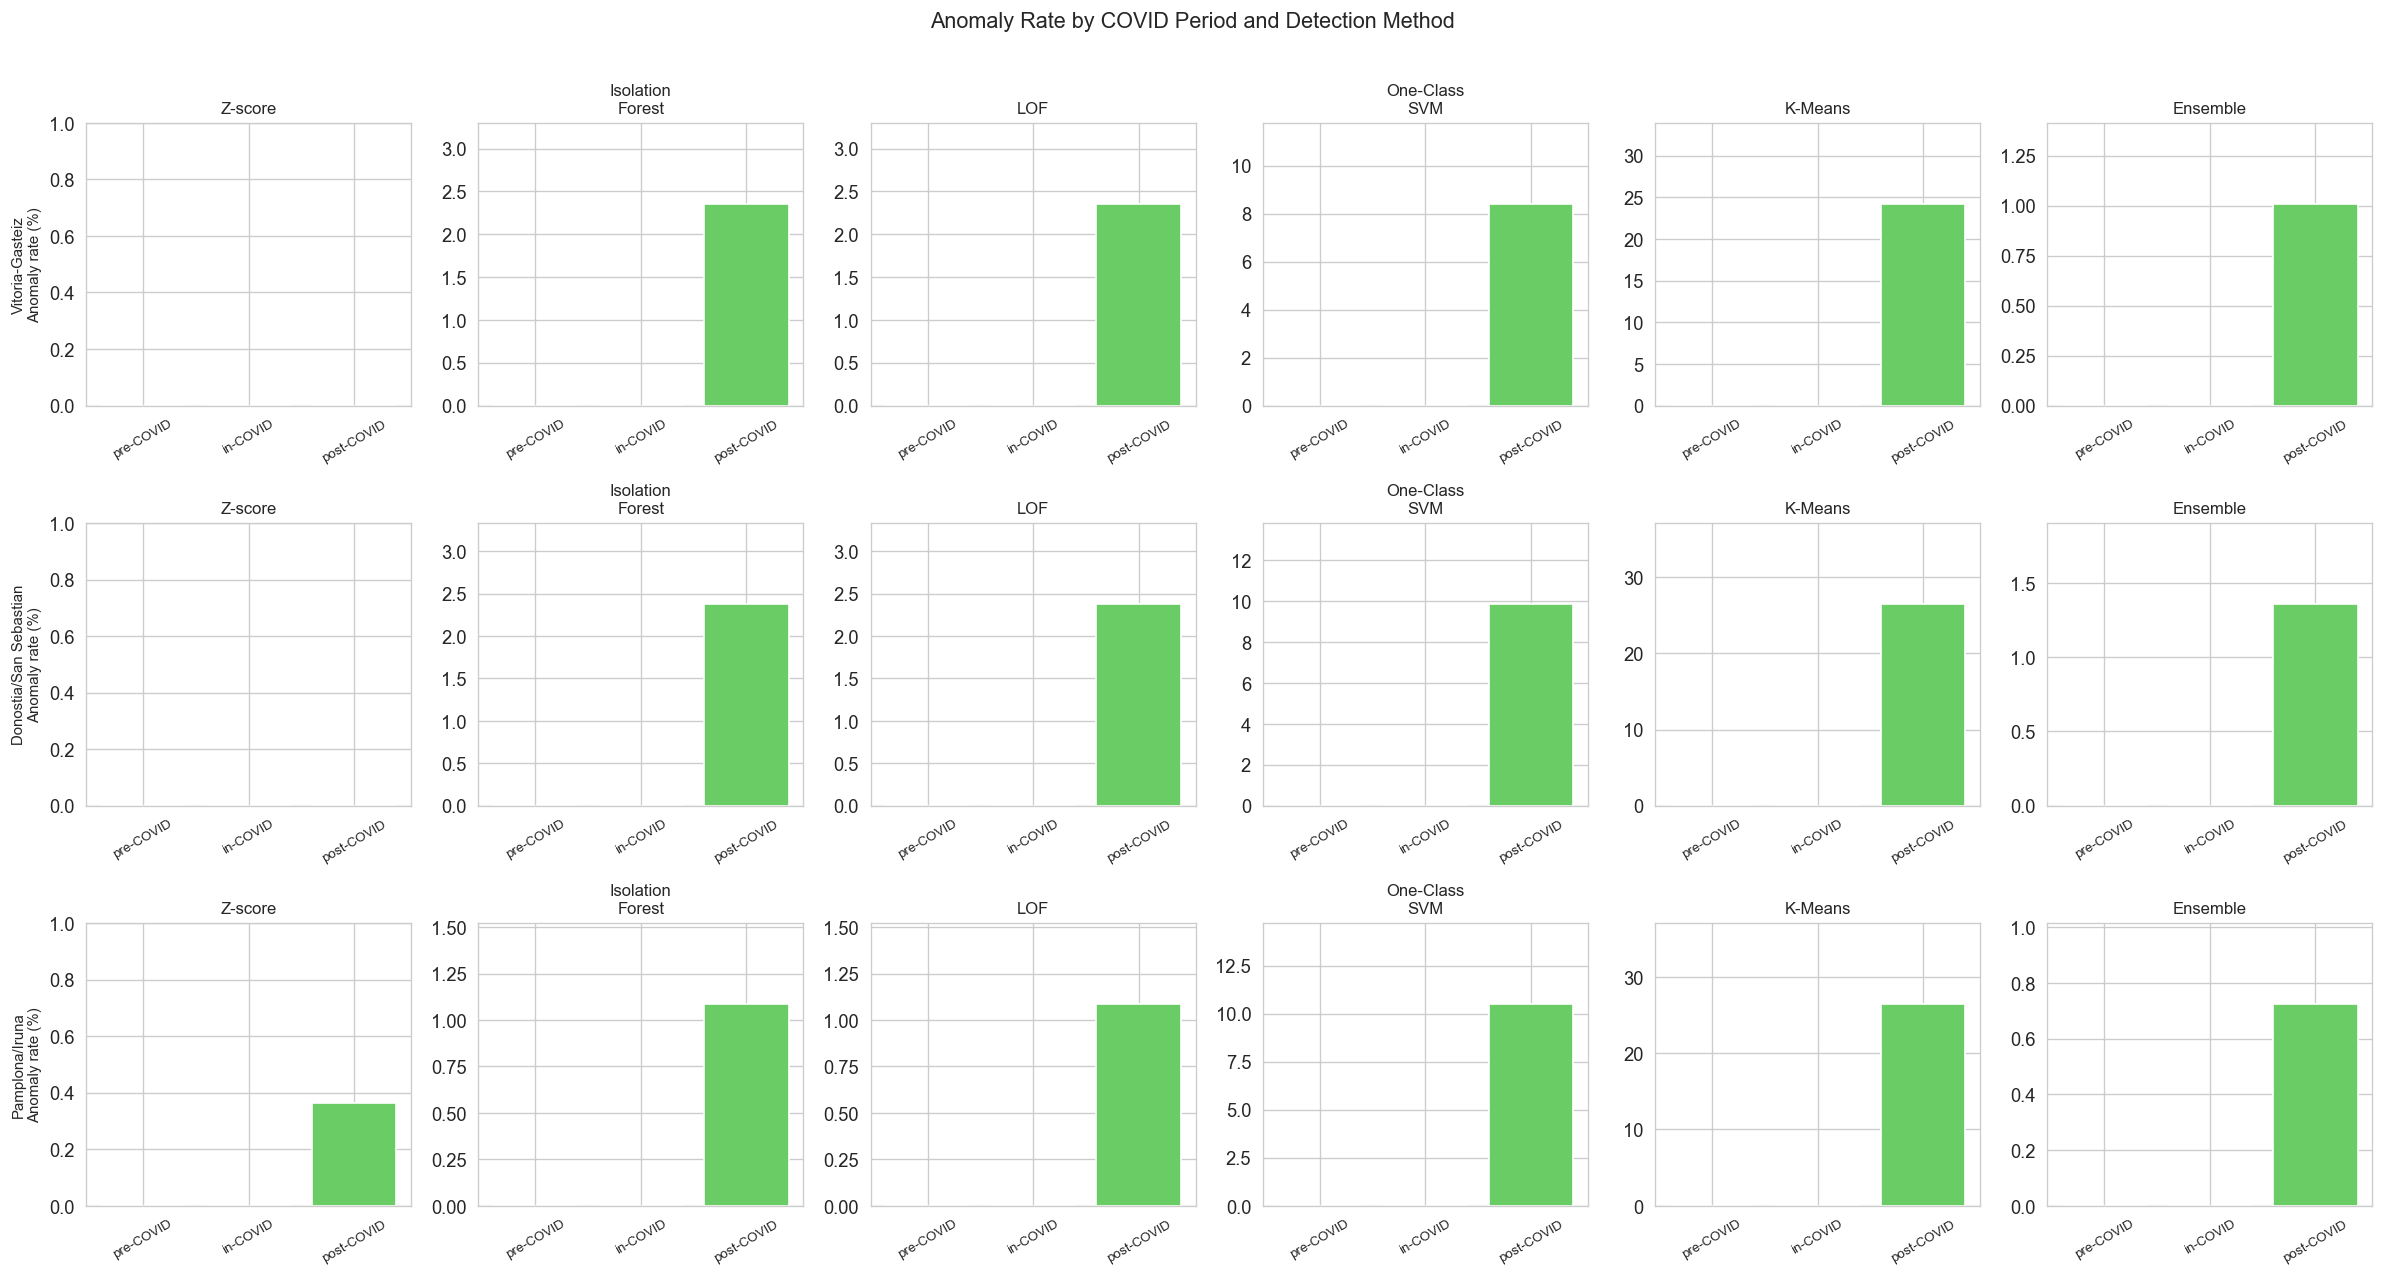

Saved temporal_distribution.png


In [4]:
flag_cols = ['zscore_flag','iforest_flag','lof_flag','ocsvm_flag','kmeans_flag','ensemble_flag']
method_labels = ['Z-score', 'Isolation\nForest', 'LOF', 'One-Class\nSVM', 'K-Means', 'Ensemble']

period_order = ['pre-COVID', 'in-COVID', 'post-COVID']
period_palette = {'pre-COVID': '#4878CF', 'in-COVID': '#D65F5F', 'post-COVID': '#6ACC65'}

fig, axes = plt.subplots(len(MUNICIPALITIES), len(flag_cols),
                          figsize=(20, 3.5 * len(MUNICIPALITIES)), sharey=False)

for row_idx, (city, df) in enumerate(results.items()):
    for col_idx, (col, label) in enumerate(zip(flag_cols, method_labels)):
        ax = axes[row_idx, col_idx]
        period_counts = (
            df[df[col] == 1]
            .groupby('period')[col]
            .count()
            .reindex(period_order, fill_value=0)
        )
        period_totals = df.groupby('period')[col].count().reindex(period_order, fill_value=1)
        period_rates  = 100 * period_counts / period_totals

        bars = ax.bar(period_order, period_rates,
                      color=[period_palette[p] for p in period_order], edgecolor='white')
        ax.set_ylim(0, max(period_rates.max() * 1.4, 1))
        ax.set_ylabel('Anomaly rate (%)' if col_idx == 0 else '')
        ax.set_title(label, fontsize=10)
        if row_idx == 0:
            pass  # title already set
        if col_idx == 0:
            ax.set_ylabel(f"{city}\nAnomaly rate (%)", fontsize=9)
        ax.tick_params(axis='x', labelrotation=30, labelsize=8)

fig.suptitle('Anomaly Rate by COVID Period and Detection Method', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'temporal_distribution.png', bbox_inches='tight')
plt.show()
print('Saved temporal_distribution.png')

## 4. Residual Time-Series with Anomaly Flags

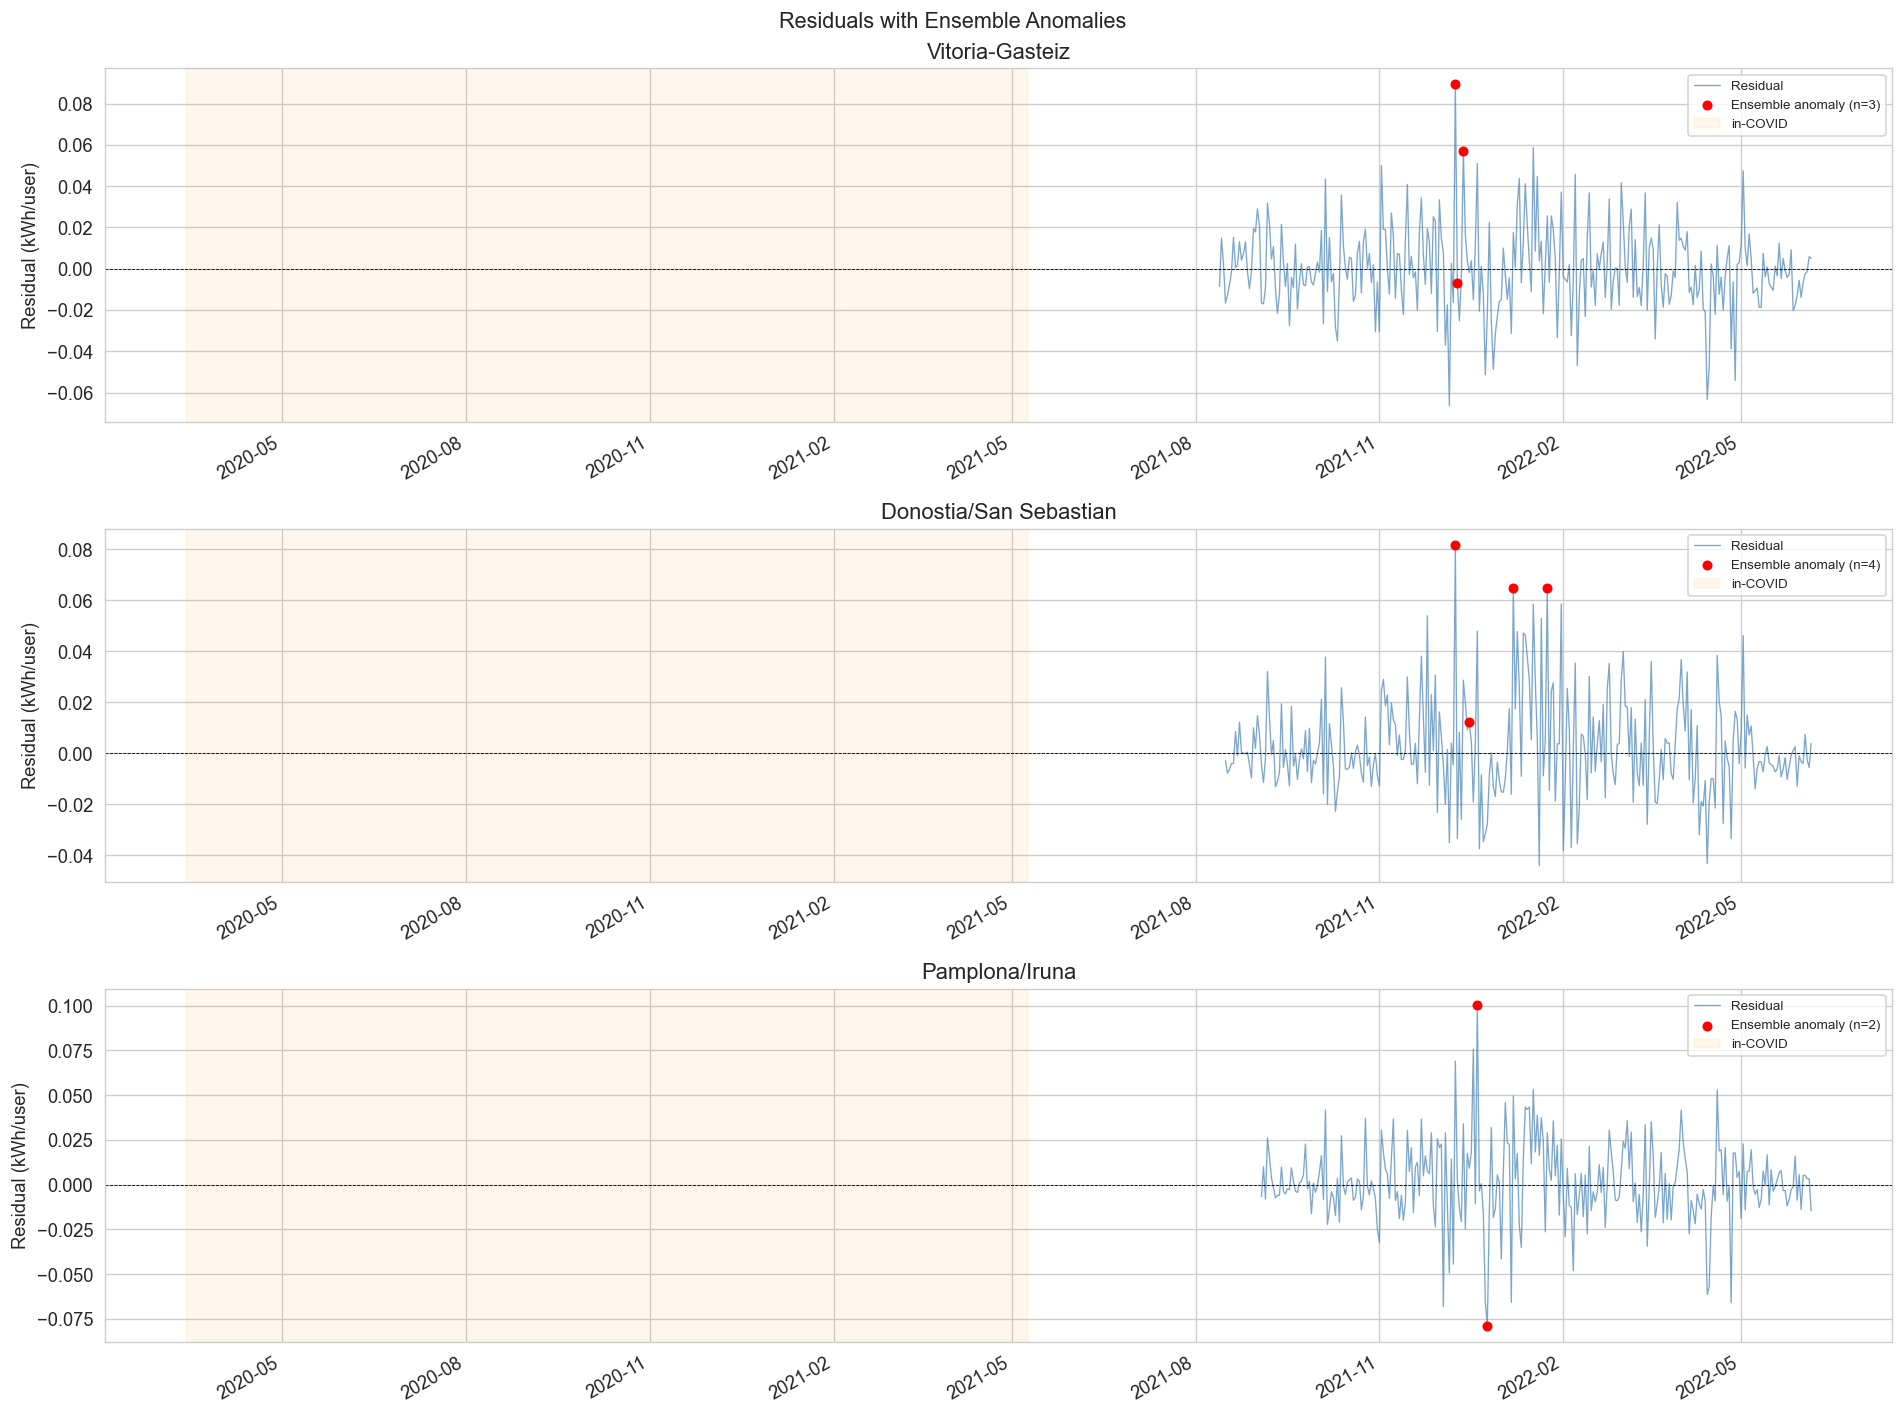

Saved residuals_with_anomalies.png


In [5]:
fig, axes = plt.subplots(len(MUNICIPALITIES), 1,
                          figsize=(16, 4 * len(MUNICIPALITIES)), sharex=False)

for ax, (city, df) in zip(axes, results.items()):
    ax.plot(df['date'], df['residual'], color='steelblue', lw=0.8, alpha=0.7, label='Residual')

    ensemble_anom = df[df['ensemble_flag'] == 1]
    ax.scatter(ensemble_anom['date'], ensemble_anom['residual'],
               color='red', s=25, zorder=5, label=f"Ensemble anomaly (n={len(ensemble_anom)})")

    # COVID shading
    ymin, ymax = ax.get_ylim()
    ax.axvspan(COVID_START, COVID_END, alpha=0.08, color='orange', label='in-COVID')

    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(city)
    ax.set_ylabel('Residual (kWh/user)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Residuals with Ensemble Anomalies', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residuals_with_anomalies.png', bbox_inches='tight')
plt.show()
print('Saved residuals_with_anomalies.png')

## 5. Cross-Method Agreement

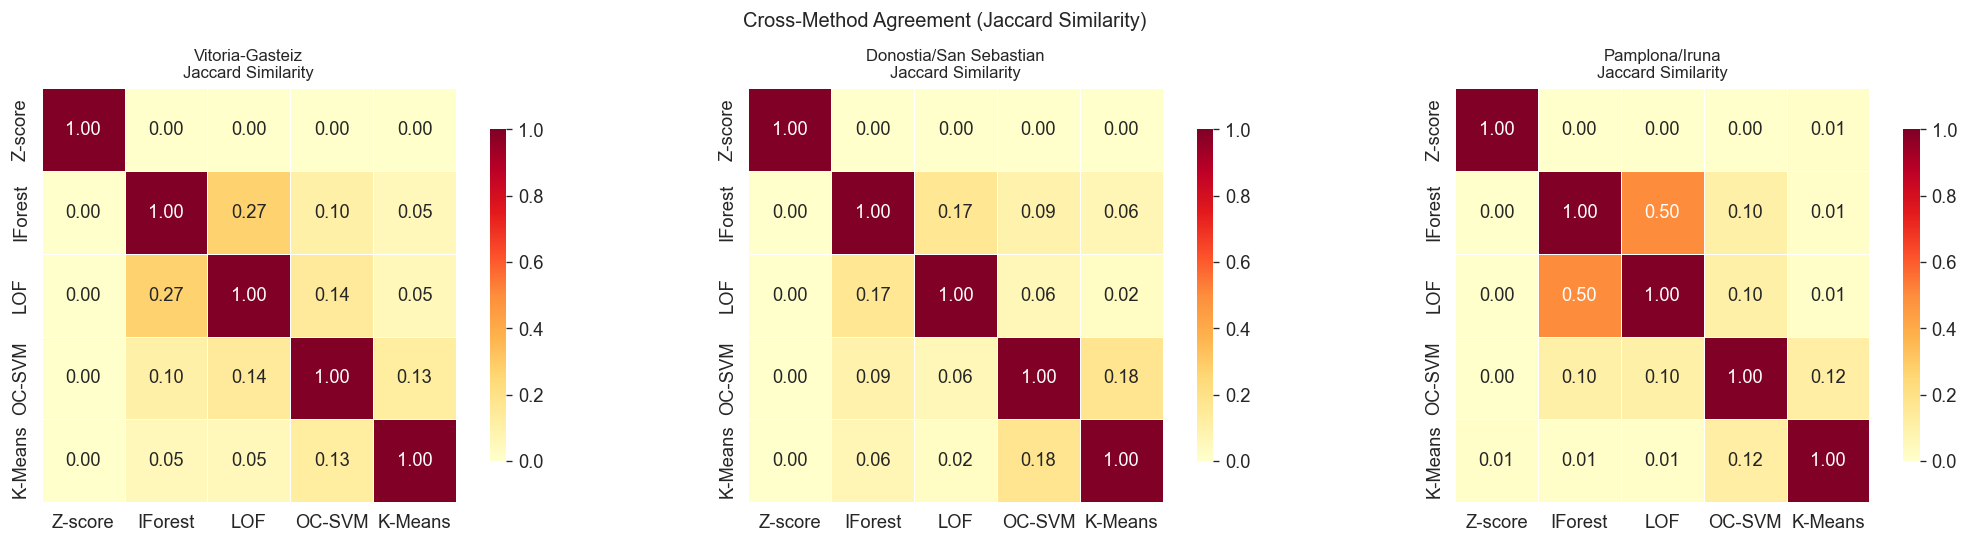

Saved cross_method_agreement.png


In [6]:
from sklearn.metrics import jaccard_score

method_names = ['Z-score', 'IForest', 'LOF', 'OC-SVM', 'K-Means']
flag_cols5   = ['zscore_flag','iforest_flag','lof_flag','ocsvm_flag','kmeans_flag']

fig, axes = plt.subplots(1, len(MUNICIPALITIES), figsize=(6 * len(MUNICIPALITIES), 4.5))

for ax, (city, df) in zip(axes, results.items()):
    n_methods = len(flag_cols5)
    jac = np.zeros((n_methods, n_methods))
    for i, c1 in enumerate(flag_cols5):
        for j, c2 in enumerate(flag_cols5):
            if df[c1].sum() == 0 and df[c2].sum() == 0:
                jac[i, j] = 1.0
            else:
                jac[i, j] = jaccard_score(df[c1], df[c2], zero_division=0)

    jac_df = pd.DataFrame(jac, index=method_names, columns=method_names)
    sns.heatmap(jac_df, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{city}\nJaccard Similarity', fontsize=10)

plt.suptitle('Cross-Method Agreement (Jaccard Similarity)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cross_method_agreement.png', bbox_inches='tight')
plt.show()
print('Saved cross_method_agreement.png')

## 6. Summary Table — Anomaly Rates per City, Method, and Period

In [7]:
rows = []
period_order = ['pre-COVID', 'in-COVID', 'post-COVID', 'ALL']

for city, df in results.items():
    for col, name in zip(flag_cols, ['Z-score','IForest','LOF','OC-SVM','K-Means','Ensemble']):
        for period in ['pre-COVID', 'in-COVID', 'post-COVID']:
            sub = df[df['period'] == period]
            rate = 100 * sub[col].mean() if len(sub) > 0 else np.nan
            rows.append({'city': city, 'method': name, 'period': period, 'anomaly_rate_%': round(rate, 2) if not np.isnan(rate) else np.nan})
        rate_all = 100 * df[col].mean()
        rows.append({'city': city, 'method': name, 'period': 'ALL', 'anomaly_rate_%': round(rate_all, 2)})

summary_df = pd.DataFrame(rows)
pivot = (
    summary_df
    .pivot_table(index=['city','method'], columns='period', values='anomaly_rate_%', aggfunc='mean')
    .reindex(columns=period_order)
)
print(pivot.to_string())

summary_df.to_csv(OUT_DIR / 'anomaly_rates_summary.csv', index=False)
pivot.to_csv(OUT_DIR / 'anomaly_rates_pivot.csv')
print('\nSaved anomaly_rates_summary.csv and anomaly_rates_pivot.csv')

period                           pre-COVID  in-COVID  post-COVID    ALL
city                   method                                          
Donostia/San Sebastian Ensemble        NaN       NaN        1.36   1.36
                       IForest         NaN       NaN        2.38   2.38
                       K-Means         NaN       NaN       26.53  26.53
                       LOF             NaN       NaN        2.38   2.38
                       OC-SVM          NaN       NaN        9.86   9.86
                       Z-score         NaN       NaN        0.00   0.00
Pamplona/Iruna         Ensemble        NaN       NaN        0.72   0.72
                       IForest         NaN       NaN        1.09   1.09
                       K-Means         NaN       NaN       26.45  26.45
                       LOF             NaN       NaN        1.09   1.09
                       OC-SVM          NaN       NaN       10.51  10.51
                       Z-score         NaN       NaN        0.36

## 7. Inspect Top Anomalous Days (Ensemble)

In [8]:
for city, df in results.items():
    anom = (
        df[df['ensemble_flag'] == 1]
        .sort_values('z_residual', key=lambda s: s.abs(), ascending=False)
        [['date', 'actual', BEST_MODEL, 'residual', 'z_residual', 'period', 'ensemble_votes']]
        .head(15)
    )
    print(f"\n{'='*60}")
    print(f"  {city} — top ensemble anomalies")
    print(f"{'='*60}")
    print(anom.to_string(index=False))


  Vitoria-Gasteiz — top ensemble anomalies
      date   actual  N-BEATS v2 (covariate-conditioned)  residual  z_residual     period  ensemble_votes
2021-12-09 0.411623                            0.322379  0.089245    2.869122 post-COVID               4
2021-12-13 0.381119                            0.324173  0.056946    1.762258 post-COVID               3
2021-12-10 0.384428                            0.391131 -0.006703   -0.273562 post-COVID               4

  Donostia/San Sebastian — top ensemble anomalies
      date   actual  N-BEATS v2 (covariate-conditioned)  residual  z_residual     period  ensemble_votes
2021-12-09 0.509665                            0.427850  0.081815    2.849653 post-COVID               3
2022-01-07 0.434247                            0.369513  0.064733    1.902287 post-COVID               3
2022-01-24 0.518632                            0.453969  0.064663    1.641305 post-COVID               3
2021-12-16 0.491452                            0.479318  0.012134

## 8. Residual Distribution — Anomalies vs Normal Days

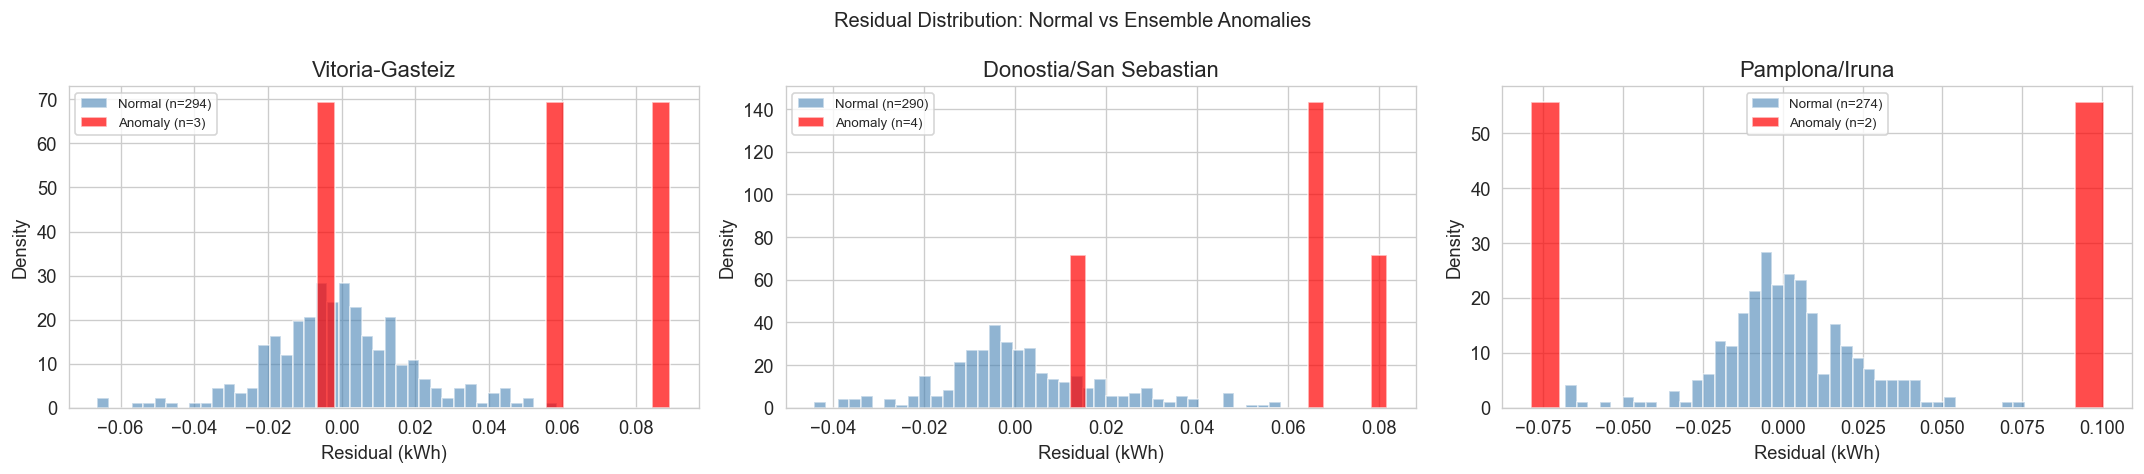

Saved residual_distribution.png


In [9]:
fig, axes = plt.subplots(1, len(MUNICIPALITIES), figsize=(6 * len(MUNICIPALITIES), 4))

for ax, (city, df) in zip(axes, results.items()):
    normal = df[df['ensemble_flag'] == 0]['residual']
    anom   = df[df['ensemble_flag'] == 1]['residual']

    ax.hist(normal, bins=40, alpha=0.6, color='steelblue', label=f'Normal (n={len(normal)})', density=True)
    ax.hist(anom,   bins=20, alpha=0.7, color='red',       label=f'Anomaly (n={len(anom)})',  density=True)
    ax.set_xlabel('Residual (kWh)')
    ax.set_ylabel('Density')
    ax.set_title(city)
    ax.legend(fontsize=8)

plt.suptitle('Residual Distribution: Normal vs Ensemble Anomalies', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_distribution.png', bbox_inches='tight')
plt.show()
print('Saved residual_distribution.png')

## 9. Save Full Anomaly Tables

In [10]:
for city, df in results.items():
    safe = city.replace('/', '_').replace(' ', '_')
    path = OUT_DIR / f'{safe}_anomaly_flags.csv'
    df.to_csv(path, index=False)
    print(f'Saved {path.name}')

print('\nAll results saved to:', OUT_DIR)

Saved Vitoria-Gasteiz_anomaly_flags.csv
Saved Donostia_San_Sebastian_anomaly_flags.csv
Saved Pamplona_Iruna_anomaly_flags.csv

All results saved to: c:\Users\GONCA\Desktop\Iscte\MCD\Theses\anomaly_detection_results_improved
